# Calibración post-hoc — corregir probabilidades

## Objetivo del notebook
Aplicar técnicas de **calibración post-hoc** para corregir las probabilidades
de modelos ya entrenados, sin modificar su arquitectura ni su entrenamiento.

El objetivo es que las probabilidades:
- sean más coherentes con la frecuencia real,
- reduzcan el overconfidence,
- y puedan usarse para tomar decisiones.

---

## Alcance
- Modelos:
  - Regresión Logística
  - Árbol de Decisión
- Técnicas de calibración:
  - Platt Scaling (sigmoid)
  - Isotonic Regression
- Métricas de evaluación:
  - Brier Score
  - Expected Calibration Error (ECE)
- Visualización:
  - Reliability diagrams (antes vs después)

---

## Regla clave
La calibración **no mejora la capacidad predictiva del modelo**.
Solo corrige **cómo expresa su confianza**.

Accuracy y AUROC no son el foco en este notebook.

## 2) Reconstrucción del experimento base y split de calibración

### ¿Qué vamos a hacer?
Vamos a reconstruir exactamente el mismo experimento base
(dataset, split y modelos), pero ahora separaremos explícitamente
un **conjunto de calibración**.

Tendremos tres conjuntos:
- **train**: entrenar el modelo
- **calibration**: ajustar la calibración
- **test**: evaluar resultados finales

---

### ¿Por qué importa?
La calibración aprende una transformación sobre probabilidades.
Si usamos el conjunto de prueba para calibrar,
estaríamos “mirando las respuestas” y falseando los resultados.

Este paso garantiza una evaluación honesta.

In [1]:
# Imports específicos del experimento
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Cargar utilidades comunes del setup
import sys
sys.path.append("../00_setup")

from environment_and_utils import (
    brier_score,
    expected_calibration_error,
    plot_reliability_diagram,
)

In [2]:
# 1) Dataset sintético (mismos parámetros)
X, y = make_classification(
    n_samples=4000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.05,
    random_state=42
)

# 2) Split inicial: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# 3) Split temp → calibration + test
X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

X_train.shape, X_cal.shape, X_test.shape

((2400, 10), (800, 10), (800, 10))

### Qué hace este código

Este código divide el dataset original en **tres conjuntos distintos**, usando dos separaciones consecutivas:

1. Primero, separa los datos en:
   - **60% para entrenamiento (train)**  
   - **40% temporal (temp)**  

2. Luego, toma ese 40% temporal y lo divide nuevamente en partes iguales:
   - **20% para calibración (calibration)**  
   - **20% para evaluación final (test)**  

Al final, el dataset queda distribuido así:
- 60% entrenamiento,
- 20% calibración,
- 20% test.

Esta división permite entrenar el modelo, calibrar sus probabilidades
y evaluar los resultados finales sin mezclar roles.

---

### Entrenamiento de modelos (sin cambios)
Entrenamos los modelos exactamente igual que en días anteriores.

In [3]:
# Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:
# Árbol de Decisión
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Probabilidades base (sin calibrar)
Estas probabilidades serán el **baseline** para comparar
antes vs después de calibrar.

In [5]:
# Probabilidades en calibration
probs_lr_cal = log_reg.predict_proba(X_cal)[:, 1]
probs_tree_cal = tree.predict_proba(X_cal)[:, 1]

# Probabilidades en test
probs_lr_test = log_reg.predict_proba(X_test)[:, 1]
probs_tree_test = tree.predict_proba(X_test)[:, 1]

## 3) Baseline de calibración (antes de corregir)

### ¿Qué vamos a hacer?
Antes de aplicar cualquier técnica de calibración,
vamos a **medir y visualizar** cómo se comportan las probabilidades actuales
(en su estado original).

Este baseline servirá como **punto de comparación** para evaluar
si la calibración realmente mejora algo.

---

### ¿Qué se evalúa aquí?
- **Brier Score** y **ECE** sobre el conjunto de test.
- **Reliability diagrams** para ver visualmente la calibración.

### 3.1) Métricas de calibración — Baseline

In [6]:
# Métricas baseline en test
brier_lr_base = brier_score(y_test, probs_lr_test)
brier_tree_base = brier_score(y_test, probs_tree_test)

ece_lr_base = expected_calibration_error(y_test, probs_lr_test, n_bins=10)
ece_tree_base = expected_calibration_error(y_test, probs_tree_test, n_bins=10)

brier_lr_base, brier_tree_base, ece_lr_base, ece_tree_base

(0.14812021178783374,
 0.11477555168549657,
 0.07165364027757408,
 0.037331655188929544)

### Interpretación — Métricas baseline (antes de calibrar)

Estos valores describen **cómo se comportan las probabilidades actuales**,
antes de aplicar cualquier técnica de calibración.

- **Brier Score**
  - Regresión Logística: ~0.15
  - Árbol de Decisión: ~0.11  
  → En promedio, el Árbol de Decisión produce probabilidades más cercanas
  al resultado real.

- **ECE**
  - Regresión Logística: ~0.07
  - Árbol de Decisión: ~0.04  
  → El Árbol de Decisión está mejor calibrado en términos promedio:
  cuando dice “X%”, ese número se acerca más a lo que ocurre.

Lectura rápida:
en promedio, el Árbol “habla mejor” que la Regresión Logística,
pero esto no elimina el riesgo de errores con alta confianza
que ya observamos en días anteriores.

---

### 3.2) Reliability diagrams — Baseline

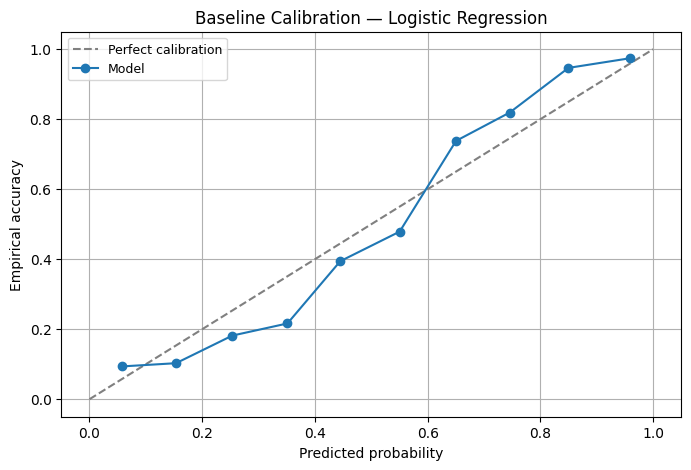

In [7]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_lr_test,
    n_bins=10,
    title="Baseline Calibration — Logistic Regression"
)

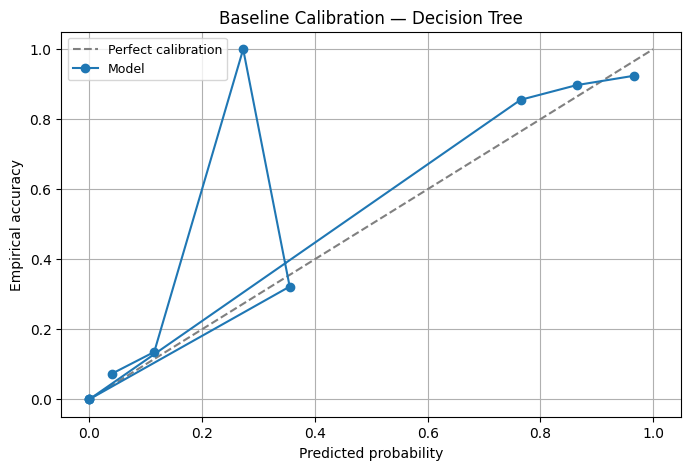

In [8]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_tree_test,
    n_bins=10,
    title="Baseline Calibration — Decision Tree"
)

### Qué queda listo
Con estas métricas y gráficos dejamos fijado el **estado inicial**:
- cómo hablan los modelos hoy,
- dónde exageran su seguridad,
- y qué tan lejos están de la calibración ideal.

A partir de aquí, cualquier mejora o empeoramiento
podrá compararse de forma objetiva.

---
---

## 4) Platt Scaling (sigmoid)

### ¿Qué vamos a hacer?
Aplicar **Platt Scaling**, una técnica de calibración **paramétrica**
que aprende una transformación sigmoidal sobre las probabilidades del modelo.

No cambia el modelo.
Solo aprende **cómo ajustar sus probabilidades** usando el conjunto de calibración.

---

### ¿Cuándo funciona bien?
- Cuando la relación entre score y probabilidad es suave.
- Cuando hay suficiente datos de calibración.
- Suele funcionar bien con modelos lineales.

### Limitación
- Es una transformación global.
- No corrige bien patrones muy irregulares.

### 4.1) Ajustar calibración con Platt Scaling
Usamos el conjunto **calibration** para aprender la transformación.

In [9]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [16]:
# Platt Scaling para Regresión Logística (modelo ya entrenado)
platt_lr = CalibratedClassifierCV(
    estimator=FrozenEstimator(log_reg),
    method="sigmoid",
)
platt_lr.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...dom_state=42))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. dep

In [17]:
# Platt Scaling para Árbol de Decisión (modelo ya entrenado)
platt_tree = CalibratedClassifierCV(
    estimator=FrozenEstimator(tree),
    method="sigmoid",
)
platt_tree.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...dom_state=42))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random spl

### 4.2) Probabilidades calibradas (test)

In [18]:
probs_lr_platt = platt_lr.predict_proba(X_test)[:, 1]
probs_tree_platt = platt_tree.predict_proba(X_test)[:, 1]

### 4.3) Métricas después de Platt Scaling
Comparamos contra el baseline.

In [19]:
brier_lr_platt = brier_score(y_test, probs_lr_platt)
brier_tree_platt = brier_score(y_test, probs_tree_platt)

ece_lr_platt = expected_calibration_error(y_test, probs_lr_platt, n_bins=10)
ece_tree_platt = expected_calibration_error(y_test, probs_tree_platt, n_bins=10)

brier_lr_platt, brier_tree_platt, ece_lr_platt, ece_tree_platt

(0.149401562102365,
 0.1140983497820526,
 0.07536022356204765,
 0.035685068227639456)

### 4.4) Reliability diagrams — Platt Scaling

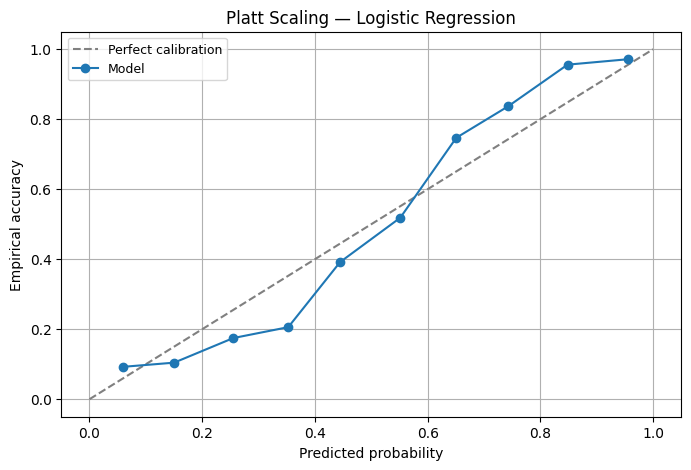

In [20]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_lr_platt,
    n_bins=10,
    title="Platt Scaling — Logistic Regression"
)

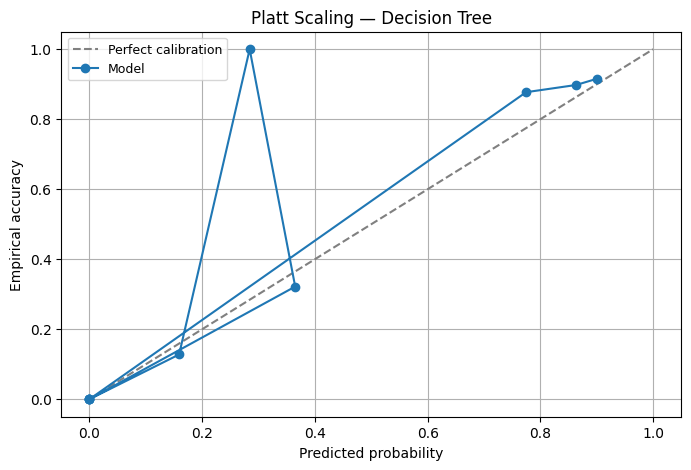

In [21]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_tree_platt,
    n_bins=10,
    title="Platt Scaling — Decision Tree"
)

### Comparación — Baseline vs Platt Scaling

Después de aplicar **Platt Scaling**, observamos cambios **leves** en las métricas:

- **Regresión Logística**
  - Brier: pasa de ~0.148 a ~0.149  
  - ECE: pasa de ~0.072 a ~0.075  

  → En este caso, Platt Scaling **no mejora** la calibración.
  Las probabilidades incluso se degradan ligeramente.
  Esto indica que el modelo ya estaba razonablemente calibrado
  y la transformación sigmoidal no aporta valor adicional.

- **Árbol de Decisión**
  - Brier: pasa de ~0.115 a ~0.114  
  - ECE: pasa de ~0.037 a ~0.036  

  → Aquí sí hay una **mejora pequeña pero consistente**.
  Platt Scaling logra suavizar ligeramente el overconfidence del árbol,
  aunque el efecto es moderado.

### Lectura clave
Platt Scaling **no es una solución universal**:
- puede no ayudar (o incluso empeorar) en modelos ya estables,
- y tiende a ayudar más en modelos con confianza abrupta,
  como los Árboles de Decisión.

Esto refuerza una idea central del laboratorio:
**calibrar es una decisión técnica, no un paso automático**.

---
---

## 5) Isotonic Regression

### ¿Qué vamos a hacer?
Aplicar **Isotonic Regression**, una técnica de calibración **no paramétrica**
que aprende una transformación flexible (monótona) sobre las probabilidades.

A diferencia de Platt Scaling:
- no asume forma sigmoidal,
- puede adaptarse mejor a patrones irregulares,
- pero corre mayor riesgo de **overfitting** si hay pocos datos.

---

### ¿Cuándo tiene sentido usarla?
- Cuando el modelo muestra calibración irregular.
- Cuando hay suficiente conjunto de calibración.
- Especialmente útil en modelos no lineales.

### 5.1) Ajustar calibración con Isotonic Regression
Usamos exclusivamente el conjunto **calibration**.

In [22]:
# Isotonic Regression para Regresión Logística
iso_lr = CalibratedClassifierCV(
    estimator=FrozenEstimator(log_reg),
    method="isotonic",
)
iso_lr.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...dom_state=42))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. de

In [23]:
# Isotonic Regression para Árbol de Decisión
iso_tree = CalibratedClassifierCV(
    estimator=FrozenEstimator(tree),
    method="isotonic",
)
iso_tree.fit(X_cal, y_cal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...dom_state=42))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random sp

### 5.2) Probabilidades calibradas (test)

In [24]:
probs_lr_iso = iso_lr.predict_proba(X_test)[:, 1]
probs_tree_iso = iso_tree.predict_proba(X_test)[:, 1]

### 5.3) Métricas después de Isotonic Regression
Comparamos contra baseline y Platt Scaling.

In [25]:
brier_lr_iso = brier_score(y_test, probs_lr_iso)
brier_tree_iso = brier_score(y_test, probs_tree_iso)

ece_lr_iso = expected_calibration_error(y_test, probs_lr_iso, n_bins=10)
ece_tree_iso = expected_calibration_error(y_test, probs_tree_iso, n_bins=10)

brier_lr_iso, brier_tree_iso, ece_lr_iso, ece_tree_iso

(0.14515302229535007,
 0.11392868944956777,
 0.036640555659339845,
 0.0326359343581098)

### 5.4) Reliability diagrams — Isotonic Regression

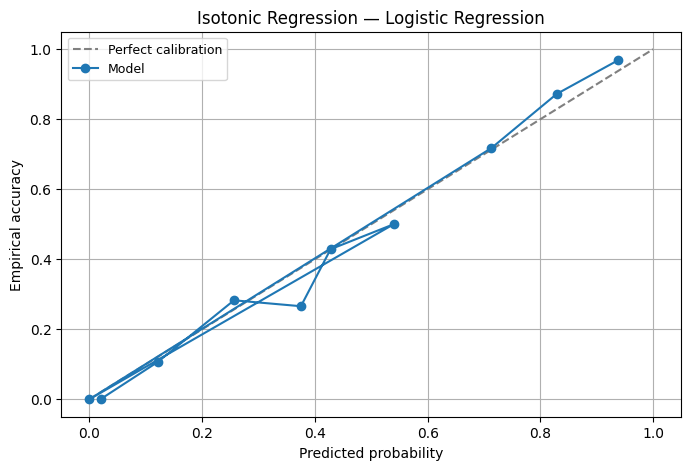

In [26]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_lr_iso,
    n_bins=10,
    title="Isotonic Regression — Logistic Regression"
)

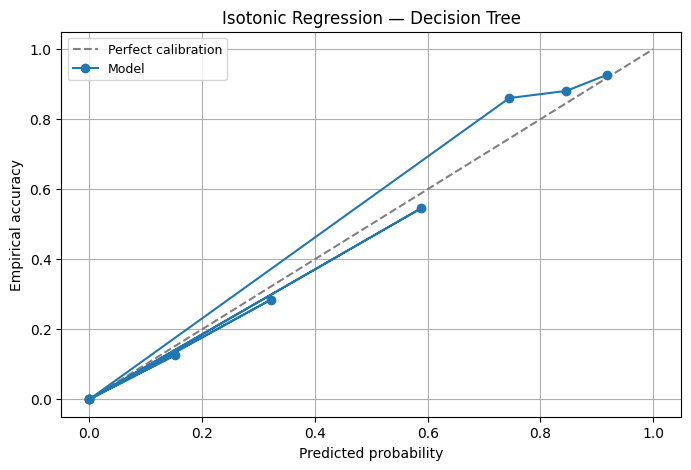

In [27]:
plot_reliability_diagram(
    y_true=y_test,
    y_prob=probs_tree_iso,
    n_bins=10,
    title="Isotonic Regression — Decision Tree"
)

### Interpretación — Isotonic Regression (resultados y gráficas)

**Métricas**
- **Regresión Logística**
  - Brier ↓ de ~0.148 a ~0.145
  - ECE ↓ fuerte de ~0.072 a ~0.037  
  → La calibración **mejora claramente**: las probabilidades ahora reflejan mucho mejor la frecuencia real.

- **Árbol de Decisión**
  - Brier ↓ levemente de ~0.115 a ~0.114
  - ECE ↓ de ~0.037 a ~0.033  
  → Mejora **moderada**: el árbol ya estaba razonablemente calibrado en promedio; Isotonic afina, pero no transforma.

**Gráficas**
- En **Logistic Regression**, la curva se pega más a la diagonal en casi todo el rango: señal de **mejor alineación probabilidad–realidad**.
- En **Decision Tree**, la curva se suaviza y se acerca a la diagonal, pero conserva tramos “en bloques”, propios del modelo.

**Conclusión**
Isotonic Regression es **muy efectiva** cuando la calibración es irregular (LR en este caso),
y **útil pero con retornos decrecientes** cuando el modelo ya estaba bien en promedio (Tree).
Hay mejora sin señales evidentes de overfitting con el tamaño de calibración usado.

---
---

## Cierre del Día 3 — Comparación y decisión técnica

### Resumen de resultados (test)

**Regresión Logística**
- Baseline:  
  - Brier ≈ 0.148 | ECE ≈ 0.072
- Platt Scaling:  
  - Sin mejora (ligera degradación)
- Isotonic Regression:  
  - Brier ≈ 0.145 | **ECE ≈ 0.037** (mejora clara)

**Árbol de Decisión**
- Baseline:  
  - Brier ≈ 0.115 | ECE ≈ 0.037
- Platt Scaling:  
  - Mejora leve
- Isotonic Regression:  
  - Brier ≈ 0.114 | ECE ≈ 0.033 (mejora moderada)

---

### Lectura clave
- **Platt Scaling**:
  - Útil para modelos con relación score–probabilidad suave.
  - No aporta valor cuando el modelo ya está razonablemente calibrado.
- **Isotonic Regression**:
  - Más flexible y efectiva cuando hay irregularidades.
  - Requiere suficiente set de calibración para evitar overfitting.

---

### Decisión técnica
- **Regresión Logística** → **Isotonic Regression** es la mejor opción.
- **Árbol de Decisión** → Calibrar aporta poco; si se usa, Isotonic mejora marginalmente.

**Regla práctica**:
> Calibrar solo cuando la auditoría lo justifica.  
> Elegir la técnica según el patrón del modelo, no por defecto.

---

### Qué cambia a partir de aquí
Ahora tenemos probabilidades:
- más coherentes,
- menos sobreconfiadas,
- y más aptas para decisiones.

---

### Próximo paso
**Día 4 — Incertidumbre por variabilidad**:
- ensembles,
- variación entre inferencias,
- convertir variabilidad en señal operativa.

---
---

## Guardar modelos calibrados

In [28]:
import joblib

### Guardar Regresión Logística calibrada (Platt / Isotonic)

In [29]:
joblib.dump(platt_lr, "logistic_platt_calibrated.joblib")
joblib.dump(iso_lr, "logistic_isotonic_calibrated.joblib")

['logistic_isotonic_calibrated.joblib']

### Guardar Árbol de Decisión calibrado (Platt / Isotonic)

In [30]:
joblib.dump(platt_tree, "tree_platt_calibrated.joblib")
joblib.dump(iso_tree, "tree_isotonic_calibrated.joblib")

['tree_isotonic_calibrated.joblib']

---
---

## Cargar en producción

1️⃣ Crear una tabla con 10 observaciones ficticias

In [48]:
import pandas as pd
import numpy as np

# Crear datos de ejemplo (10 filas, 10 features)
X_new = pd.DataFrame(
    np.random.randn(10, 10),
    columns=[f"feature_{i}" for i in range(10)]
)

X_new

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,-0.828995,-0.560181,0.747294,0.610370,-0.020902,0.117327,1.277665,-0.591571,0.547097,-0.202193
1,-0.217681,1.098777,0.825416,0.813510,1.305479,0.021004,0.681953,-0.310267,0.324166,-0.130143
2,0.096996,0.595157,-0.818221,2.092387,-1.006017,-1.214189,1.158111,0.791663,0.624120,0.628346
3,-0.012247,-0.897254,0.075805,-0.677162,0.975120,-0.147057,-0.825497,-0.321386,0.412931,-0.563725
4,-0.822220,0.243687,0.244967,-0.506943,-0.471038,0.232050,-1.448084,-1.407464,-0.718444,-0.213447
5,0.310908,1.475356,0.857660,-0.159939,-0.019016,-1.002529,-0.018513,-0.288659,0.322719,-0.827231
6,0.519347,1.532739,-0.108760,0.401712,0.690144,-0.401220,0.224092,0.012592,0.097676,-0.773010
7,0.024510,0.497998,1.451144,0.959271,2.153182,-0.767348,0.872321,0.183342,2.189803,-0.808298
8,-0.839722,-0.599393,-2.123896,-0.525755,-0.759133,0.150394,0.341756,1.876171,0.950424,-0.576904
9,-0.898415,0.491919,-1.320233,1.831459,1.179440,-0.469176,-1.713135,1.353872,-0.114540,1.237816


2️⃣ Cargar el modelo calibrado

In [49]:
import joblib

model = joblib.load("logistic_isotonic_calibrated.joblib")

3️⃣ Obtener probabilidades calibradas

In [50]:
probs_all = model.predict_proba(X_new)

X_new["prob_0"] = probs_all[:, 0]
X_new["prob_1"] = probs_all[:, 1]

X_new

g:\Dekano\ml-uncertainty-lab\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,prob_0,prob_1
0,-0.828995,-0.560181,0.747294,0.610370,-0.020902,0.117327,1.277665,-0.591571,0.547097,-0.202193,0.169492,0.830508
1,-0.217681,1.098777,0.825416,0.813510,1.305479,0.021004,0.681953,-0.310267,0.324166,-0.130143,0.286765,0.713235
2,0.096996,0.595157,-0.818221,2.092387,-1.006017,-1.214189,1.158111,0.791663,0.624120,0.628346,0.169492,0.830508
3,-0.012247,-0.897254,0.075805,-0.677162,0.975120,-0.147057,-0.825497,-0.321386,0.412931,-0.563725,0.286765,0.713235
4,-0.822220,0.243687,0.244967,-0.506943,-0.471038,0.232050,-1.448084,-1.407464,-0.718444,-0.213447,0.286765,0.713235
5,0.310908,1.475356,0.857660,-0.159939,-0.019016,-1.002529,-0.018513,-0.288659,0.322719,-0.827231,0.286765,0.713235
6,0.519347,1.532739,-0.108760,0.401712,0.690144,-0.401220,0.224092,0.012592,0.097676,-0.773010,0.286765,0.713235
7,0.024510,0.497998,1.451144,0.959271,2.153182,-0.767348,0.872321,0.183342,2.189803,-0.808298,0.286765,0.713235
8,-0.839722,-0.599393,-2.123896,-0.525755,-0.759133,0.150394,0.341756,1.876171,0.950424,-0.576904,0.061856,0.938144
9,-0.898415,0.491919,-1.320233,1.831459,1.179440,-0.469176,-1.713135,1.353872,-0.114540,1.237816,0.286765,0.713235
